In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image

In [20]:
!pip install kaggle

In [21]:
# configuring the path of Kaggle-2.json file
!mkdir -p ~/.kaggle-2
!cp kaggle-2.json ~/.kaggle-2/
!chmod 600 ~/.kaggle-2/kaggle-2.json

In [22]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [23]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [24]:
!ls

data  face-mask-dataset.zip  kaggle-2.json  sample_data


In [25]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_3594.jpg', 'with_mask_2385.jpg', 'with_mask_1974.jpg', 'with_mask_2822.jpg', 'with_mask_3709.jpg']
['with_mask_2565.jpg', 'with_mask_540.jpg', 'with_mask_2366.jpg', 'with_mask_3491.jpg', 'with_mask_3304.jpg']


In [26]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3079.jpg', 'without_mask_3688.jpg', 'without_mask_689.jpg', 'without_mask_3514.jpg', 'without_mask_2542.jpg']
['without_mask_3785.jpg', 'without_mask_767.jpg', 'without_mask_1896.jpg', 'without_mask_3554.jpg', 'without_mask_583.jpg']


In [27]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [28]:
with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [29]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [30]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [31]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


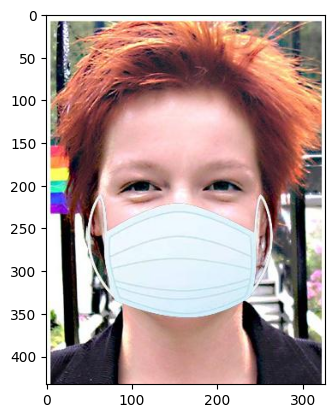

In [32]:
img = mpimg.imread('/content/data/with_mask/with_mask_1505.jpg')
imgplot = plt.imshow(img)
plt.show()

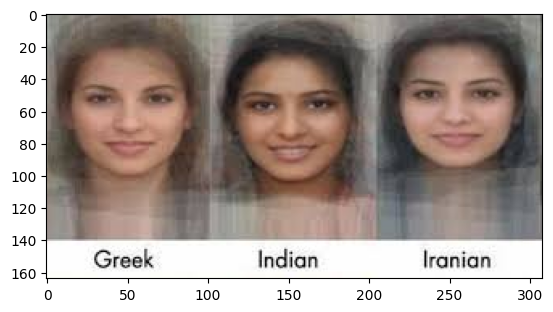

In [33]:
img = mpimg.imread('/content/data/without_mask/without_mask_2025.jpg')
imgplot = plt.imshow(img)
plt.show()

In [34]:
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [35]:
type(data)

list

In [36]:
len(data)

7553

array([[[201, 206, 202],
        [201, 207, 203],
        [204, 207, 203],
        ...,
        [235, 234, 229],
        [233, 232, 227],
        [233, 232, 227]],

       [[198, 203, 199],
        [198, 204, 199],
        [201, 205, 200],
        ...,
        [237, 236, 231],
        [234, 234, 229],
        [234, 233, 228]],

       [[199, 202, 198],
        [199, 203, 197],
        [201, 204, 198],
        ...,
        [234, 231, 227],
        [230, 228, 223],
        [229, 226, 222]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
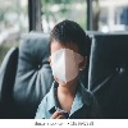

In [37]:
data[0]

In [38]:
type(data[0])

numpy.ndarray

In [39]:
data[0].shape

(128, 128, 3)

In [40]:
X = np.array(data)
Y = np.array(labels)

In [41]:
type(X)

numpy.ndarray

In [42]:
type(Y)

numpy.ndarray

In [43]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [44]:
print(Y)

[1 1 1 ... 0 0 0]


In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [49]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [50]:
X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[226, 227, 232],
        [225, 226, 231],
        [225, 226, 231],
        ...,
        [216, 214, 217],
        [216, 214, 217],
        [216, 214, 216]],

       [[226, 227, 232],
        [226, 227, 232],
        [225, 226, 231],
        ...,
        [216, 214, 217],
        [216, 214, 217],
        [216, 214, 216]],

       [[227, 228, 233],
        [227, 228, 233],
        [226, 227, 232],
        ...,
        [216, 214, 217],
        [216, 214, 217],
        [216, 214, 216]],

       ...,

       [[225, 225, 233],
        [225, 225, 233],
        [225, 225, 233],
        ...,
        [203, 203, 205],
        [204, 204, 206],
        [206, 206, 208]],

       [[225, 225, 233],
        [225, 225, 233],
        [225, 225, 233],
        ...,
        [202, 202, 204],
        [202, 202, 204],
        [204, 204, 206]],

       [[225, 225, 233],
        [225, 225, 233],
        [225, 225, 233],
        ...,
        [203, 199, 201],
        [204, 201, 203],
        [206, 203, 205]]], dtype=uint8)
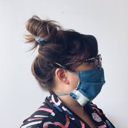

In [51]:
X_train[0]

In [52]:
X_train_scaled[0]

array([[[0.88627451, 0.89019608, 0.90980392],
        [0.88235294, 0.88627451, 0.90588235],
        [0.88235294, 0.88627451, 0.90588235],
        ...,
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.84705882]],

       [[0.88627451, 0.89019608, 0.90980392],
        [0.88627451, 0.89019608, 0.90980392],
        [0.88235294, 0.88627451, 0.90588235],
        ...,
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.84705882]],

       [[0.89019608, 0.89411765, 0.91372549],
        [0.89019608, 0.89411765, 0.91372549],
        [0.88627451, 0.89019608, 0.90980392],
        ...,
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.85098039],
        [0.84705882, 0.83921569, 0.84705882]],

       ...,

       [[0.88235294, 0.88235294, 0.91372549],
        [0.88235294, 0.88235294, 0.91372549],
        [0.88235294, 0

In [53]:
import tensorflow as tf
from tensorflow import keras

In [54]:
num_of_classes = 2

model = keras.Sequential([

    keras.layers.Input(shape=(128,128,3)),

    # Data Augmentation
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomZoom(0.10),

    # CNN Block 1
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    # CNN Block 2
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    # CNN Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    # CNN Block 4
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    # Reduce parameters
    keras.layers.GlobalAveragePooling2D(),

    # Fully Connected
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),

    # Output
    keras.layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 432,130 (1.65 MB)

 Trainable params: 430,914 (1.64 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [55]:
# compile the neural network
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [58]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train_scaled,
    Y_train,
    test_size=0.1,
    random_state=42,
    stratify=Y_train
)

print(X_train_final.shape)
print(X_val.shape)

(5437, 128, 128, 3)
(605, 128, 128, 3)


In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True
)

datagen.fit(X_train_scaled)

In [63]:
history = model.fit(
    datagen.flow(
        X_train_scaled,
        Y_train,
        batch_size=32
    ),
    epochs=30,
    validation_split=0.0,
    callbacks=[early_stopping]
)

Epoch 1/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 153ms/step - accuracy: 0.9192 - loss: 0.2089
Epoch 2/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.9245 - loss: 0.1863
Epoch 3/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9308 - loss: 0.1876
Epoch 4/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9411 - loss: 0.1556
Epoch 5/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9523 - loss: 0.1318
Epoch 6/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 146ms/step - accuracy: 0.9499 - loss: 0.1358
Epoch 7/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9566 - loss: 0.1166
Epoch 8/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9578 - loss: 0.1142
Epoch 9/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9619 - loss: 0.1049
Epoch 10/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 27s 144ms/step - accuracy: 0.9633 - loss: 0.1023
Epoch 11/30
189/189 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9657 - loss: 0.0948
Epoch 12/30
189/189

In [64]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)

print("Test Loss =", loss)
print("Test Accuracy =", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9828 - loss: 0.0548
Test Loss = 0.054793957620859146
Test Accuracy = 0.982792854309082


In [70]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

input_image_path = input("Path of the image to be predicted: ")

input_image = Image.open(input_image_path)

# Same preprocessing as training
input_image = input_image.convert('RGB')
input_image = input_image.resize((128,128))

input_image = np.array(input_image)
input_image = input_image.astype('float32') / 255.0

# Add batch dimension
input_image = np.expand_dims(input_image, axis=0)

# Prediction
input_prediction = model.predict(input_image)

print("Prediction probabilities:", input_prediction)

input_pred_label = np.argmax(input_prediction, axis=1)[0]

print("Predicted label:", input_pred_label)

if input_pred_label == 1:
    print("The person in the image is wearing a mask")
else:
    print("The person in the image is not wearing a mask")

Path of the image to be predicted: /content/Screenshot 2026-09-06 at 11.34.19 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction probabilities: [[0.6710445  0.32895553]]
Predicted label: 0
The person in the image is not wearing a mask


In [72]:
# Keras format
model.save("FaceGuard-CNN_model.keras")

# PKL format
import pickle

with open("FaceGuard-CNN_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Both models saved successfully!")

Both models saved successfully!
